## Dataset Download
I referred to [this repository](https://github.com/ConstantinSeibold/2DAnatomyDatasets)

In [1]:
import os
import requests
from zipfile import ZipFile
import json
import random
from pathlib import Path
from tqdm import tqdm
import shutil
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import numpy as np
import json

In [2]:
# Define the URL and the target path
url = "https://www.kaggle.com/api/v1/datasets/download/humansintheloop/teeth-segmentation-on-dental-x-ray-images"
download_path = "/content/archive.zip"
extract_path = "/content/teeth-segmentation-on-dental-x-ray-images"

def download_and_extract(url, download_path, extract_path):
    try:
        # Create the extraction directory if it doesn't exist
        os.makedirs(extract_path, exist_ok=True)

        # Download the file
        print("Downloading dataset...")
        response = requests.get(url, stream=True)
        response.raise_for_status()  # Check for HTTP request errors
        with open(download_path, "wb") as file:
            for chunk in response.iter_content(chunk_size=8192):
                file.write(chunk)
        print("Download complete.")

        # Extract the zip file
        print("Extracting files...")
        with ZipFile(download_path, "r") as zip_ref:
            zip_ref.extractall(extract_path)
        print(f"Files extracted to {extract_path}")

    finally:
        # Remove the ZIP file
        if os.path.exists(download_path):
            os.remove(download_path)
            print("ZIP file deleted.")


# Run the function
download_and_extract(url, download_path, extract_path)

Download complete.
Extracting files...
Files extracted to /content/teeth-segmentation-on-dental-x-ray-images
ZIP file deleted.


In [3]:
def convert_to_coco(ann_dir, img_dir, output_file):
    # Initialize COCO format structure
    coco_format = {
        "info": {
            "description": "Converted Dataset",
            "version": "1.0",
            "year": 2024,
            "contributor": "",
            "date_created": "2024-11-18",
        },
        "licenses": [],
        "images": [],
        "annotations": [],
        "categories": [],
    }

    # Category mapping and ID generator
    category_id_map = {}
    annotation_id = 0  # Unique ID for annotations

    files = sorted(os.listdir(ann_dir))
    # Process each annotation file
    for ann_file in tqdm(files):
        if ann_file.endswith(".json"):
            # Load annotation JSON
            ann_path = os.path.join(ann_dir, ann_file)
            with open(ann_path, "r") as f:
                ann_data = json.load(f)

            # Extract image filename and size
            filename = ann_file.replace(".json", "")
            image_path = os.path.join(img_dir, filename)
            if not os.path.exists(image_path):
                print(f"Image file {filename} not found, skipping...")
                continue

            image_id = len(coco_format["images"]) + 1
            image_info = {
                "id": image_id,
                "file_name": filename,
                "height": ann_data["size"]["height"],
                "width": ann_data["size"]["width"],
            }
            coco_format["images"].append(image_info)

            # Process objects in the annotation
            for obj in ann_data.get("objects", []):
                class_title = obj["classTitle"]
                if class_title not in category_id_map:
                    category_id = int(class_title)
                    category_id_map[class_title] = category_id
                    coco_format["categories"].append(
                        {
                            "id": category_id,
                            "name": class_title,
                            "supercategory": "none",
                        }
                    )
                else:
                    category_id = category_id_map[class_title]

                # Convert polygon points
                points = obj["points"]["exterior"]
                segmentation = [
                    coord for point in points for coord in point
                ]  # Flatten list of points

                # Calculate bounding box (xmin, ymin, width, height)
                x_coords = [p[0] for p in points]
                y_coords = [p[1] for p in points]
                xmin, ymin = min(x_coords), min(y_coords)
                width, height = max(x_coords) - xmin, max(y_coords) - ymin

                # Add annotation
                annotation = {
                    "id": annotation_id,
                    "image_id": image_id,
                    "category_id": category_id,
                    "segmentation": [segmentation],
                    "area": width * height,
                    "bbox": [xmin, ymin, width, height],
                    "iscrowd": 0,
                }
                coco_format["annotations"].append(annotation)
                annotation_id += 1

    # Save COCO JSON to output file
    with open(output_file, "w") as f:
        json.dump(coco_format, f, indent=4)

    print(f"COCO dataset saved to {output_file}")
    return coco_format


def create_splits(coco_data, output_dir, splits=(0.7, 0.1, 0.2)):
    random.seed(42)  # For reproducibility
    images = coco_data["images"]
    random.shuffle(images)

    # Calculate split indices
    total_images = len(images)
    train_count = int(splits[0] * total_images)
    val_count = int(splits[1] * total_images)
    train_images = images[:train_count]
    val_images = images[train_count : train_count + val_count]
    test_images = images[train_count + val_count :]

    # Helper to filter annotations by image IDs
    def filter_annotations(image_ids):
        return [ann for ann in coco_data["annotations"] if ann["image_id"] in image_ids]

    # Create split datasets
    splits_data = {
        "train": {
            "images": train_images,
            "annotations": filter_annotations({img["id"] for img in train_images}),
            "categories": coco_data["categories"],
        },
        "val": {
            "images": val_images,
            "annotations": filter_annotations({img["id"] for img in val_images}),
            "categories": coco_data["categories"],
        },
        "test": {
            "images": test_images,
            "annotations": filter_annotations({img["id"] for img in test_images}),
            "categories": coco_data["categories"],
        },
    }

    # Save splits
    for split_name, split_data in splits_data.items():
        split_path = os.path.join(output_dir, f"{split_name}.json")
        with open(split_path, "w") as f:
            json.dump(split_data, f, indent=4)
        print(f"Saved {split_name} split to {split_path}")

    return splits_data


def create_class_agnostic(coco_data, output_dir, splits_data):
    for split_name, split_data in splits_data.items():
        # Replace all categories with a single class
        agnostic_data = {
            "images": split_data["images"],
            "annotations": [
                {**ann, "category_id": 1} for ann in split_data["annotations"]
            ],
            "categories": [{"id": 1, "name": "classagnostic", "supercategory": "none"}],
        }
        # Save class-agnostic file
        agnostic_path = os.path.join(output_dir, f"{split_name}_classagnostic.json")
        with open(agnostic_path, "w") as f:
            json.dump(agnostic_data, f, indent=4)
        print(f"Saved class-agnostic {split_name} to {agnostic_path}")


# Example usage
if __name__ == "__main__":
    teeth_root = "/content/teeth-segmentation-on-dental-x-ray-images"
    ann_folder = os.path.join(teeth_root, "Teeth Segmentation JSON/d2/ann")
    img_folder = os.path.join(teeth_root, "Teeth Segmentation JSON/d2/img")
    output_coco_file = os.path.join(teeth_root, "teeth_coco.json")

    # Convert to COCO format
    coco_data = convert_to_coco(ann_folder, img_folder, output_coco_file)

    # Create train/val/test splits
    splits = create_splits(coco_data, teeth_root, splits=(0.7, 0.1, 0.2))

    # Create class-agnostic files
    create_class_agnostic(coco_data, teeth_root, splits)

    shutil.move(
        os.path.join(teeth_root, "Teeth Segmentation JSON/d2/img"),
        os.path.join(teeth_root, "img"),
    )

    shutil.rmtree(os.path.join(teeth_root, "Teeth Segmentation JSON"))
    shutil.rmtree(os.path.join(teeth_root, "Teeth Segmentation PNG"))


100%|██████████| 598/598 [00:00<00:00, 812.34it/s] 


COCO dataset saved to /content/teeth-segmentation-on-dental-x-ray-images/teeth_coco.json
Saved train split to /content/teeth-segmentation-on-dental-x-ray-images/train.json
Saved val split to /content/teeth-segmentation-on-dental-x-ray-images/val.json
Saved test split to /content/teeth-segmentation-on-dental-x-ray-images/test.json
Saved class-agnostic train to /content/teeth-segmentation-on-dental-x-ray-images/train_classagnostic.json
Saved class-agnostic val to /content/teeth-segmentation-on-dental-x-ray-images/val_classagnostic.json
Saved class-agnostic test to /content/teeth-segmentation-on-dental-x-ray-images/test_classagnostic.json


In [4]:
!cd teeth-segmentation-on-dental-x-ray-images && ls

img			 test.json		   val_classagnostic.json
teeth_coco.json		 train_classagnostic.json  val.json
test_classagnostic.json  train.json


# Train

In [8]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.0 MB/s eta 0:00:00


In [9]:
from ultralytics import YOLO

# Initialize YOLO segmentation model
model = YOLO('yolov8n-seg.pt')
print('YOLO model loaded.')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO model loaded.


In [10]:
import json
import shutil
import numpy as np
from pathlib import Path
from tqdm import tqdm

# Set paths
data_dir = Path('/content/teeth-segmentation-on-dental-x-ray-images')
img_dir = data_dir / 'img'

def coco_to_yolo(split):
    json_path = data_dir / f'{split}.json'
    if not json_path.exists():
        return

    with open(json_path) as f:
        coco = json.load(f)

    yolo_img_dir = data_dir / 'images' / split
    yolo_lbl_dir = data_dir / 'labels' / split
    yolo_img_dir.mkdir(parents=True, exist_ok=True)
    yolo_lbl_dir.mkdir(parents=True, exist_ok=True)

    img_id_to_info = {img['id']: img for img in coco['images']}

    for img in tqdm(coco['images'], desc=f'Copying {split} images'):
        src = img_dir / img['file_name']
        if src.exists():
            shutil.copy(src, yolo_img_dir / img['file_name'])

    for ann in tqdm(coco['annotations'], desc=f'Converting {split} annotations'):
        img_info = img_id_to_info[ann['image_id']]
        w, h = img_info['width'], img_info['height']

        # Class ID mapping (0-indexed for YOLO)
        cls = ann['category_id'] - 1

        for seg in ann['segmentation']:
            poly = np.array(seg).reshape(-1, 2)
            poly_norm = poly / np.array([w, h])
            poly_flat = poly_norm.flatten().tolist()

            lbl_path = yolo_lbl_dir / (img_info['file_name'].rsplit('.', 1)[0] + '.txt')
            with open(lbl_path, 'a') as f:
                line = f'{cls} ' + ' '.join([f'{x:.6f}' for x in poly_flat]) + '\n'
                f.write(line)

print('Converting datasets to YOLO format...')
coco_to_yolo('train')
coco_to_yolo('val')
coco_to_yolo('test')
print('Conversion complete.')

Converting datasets to YOLO format...


Converting test annotations: 100%|██████████| 3152/3152 [00:00<00:00, 15262.05it/s]

Conversion complete.


In [11]:
import yaml

with open(data_dir / 'train.json') as f:
    coco = json.load(f)

# Extract category names and map them to 0-indexed for YOLO
categories = sorted(coco['categories'], key=lambda x: x['id'])
names = {c['id'] - 1: c['name'] for c in categories}

yaml_dict = {
    'path': str(data_dir),
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'names': names
}

yaml_path = data_dir / 'data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_dict, f, sort_keys=False)

print(f'Created YOLO data.yaml at {yaml_path}')

Created YOLO data.yaml at /content/teeth-segmentation-on-dental-x-ray-images/data.yaml


In [13]:
# Start YOLO Training (training for 10 epochs as default, adjust as needed)
results = model.train(
    data=str(data_dir / 'data.yaml'),
    epochs=10,
    imgsz=512,
    batch=16,
    project='/content/yolo_train',
    name='teeth_seg'
)

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/teeth-segmentation-on-dental-x-ray-images/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=teeth_seg, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, over

KeyboardInterrupt: 

In [15]:
from ultralytics import YOLO

# Load the last checkpoint from the interrupted training
checkpoint_path = '/content/yolo_train/teeth_seg/weights/last.pt'
resume_model = YOLO(checkpoint_path)

# Resume training for the remaining epoch(s)
print("Resuming training to finish the last epoch...")
resume_results = resume_model.train(resume=True)


Resuming training to finish the last epoch...
Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/teeth-segmentation-on-dental-x-ray-images/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/yolo_train/teeth_seg/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=t

In [32]:
# not performing very well after 10, add 5 more epochs by training on top
best_weights_path = '/content/yolo_train/teeth_seg/weights/best.pt'
model_more_epochs = YOLO(best_weights_path)

# Train for 5 additional epochs
print("Training for 5 additional epochs...")
results_more = model_more_epochs.train(
    data=str(data_dir / 'data.yaml'),
    epochs=5,
    imgsz=512,
    batch=16,
    project='/content/yolo_train',
    name='teeth_seg_more_epochs', resume=True
)

Training for 5 additional epochs...
WARNING ⚠️ model '/content/yolo_train/teeth_seg/weights/best.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/teeth-segmentation-on-dental-x-ray-images/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=

In [33]:
# Mount Google Drive to save the model permanently
from google.colab import drive
import shutil
import os

# This will prompt you to authorize access to your Google Drive
drive.mount('/content/drive')

# Define where the model is currently saved, and where you want it in your Drive
source_weights = '/content/yolo_train/teeth_seg_more_epochs-3/weights/best.pt'
drive_dest_dir = '/content/drive/MyDrive/cv2/Teeth_Segmentation_Model'

# Create the folder in your Drive if it doesn't exist
os.makedirs(drive_dest_dir, exist_ok=True)

# Copy the file over
if os.path.exists(source_weights):
    shutil.copy(source_weights, os.path.join(drive_dest_dir, 'best.pt'))
    print(f"\nSuccess! Model saved permanently to: {drive_dest_dir}/best.pt")
else:
    print("\nModel weights not found. Make sure the training cell above finished successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Success! Model saved permanently to: /content/drive/MyDrive/cv2/Teeth_Segmentation_Model/best.pt


# Post processing



image 1/1 /content/teeth-segmentation-on-dental-x-ray-images/images/test/104.jpg: 288x512 1 6, 2 8s, 1 10, 1 17, 1 19, 2 20s, 1 22, 2 25s, 1 26, 1 30, 2 31s, 90.1ms
Speed: 1.8ms preprocess, 90.1ms inference, 12.3ms postprocess per image at shape (1, 3, 288, 512)


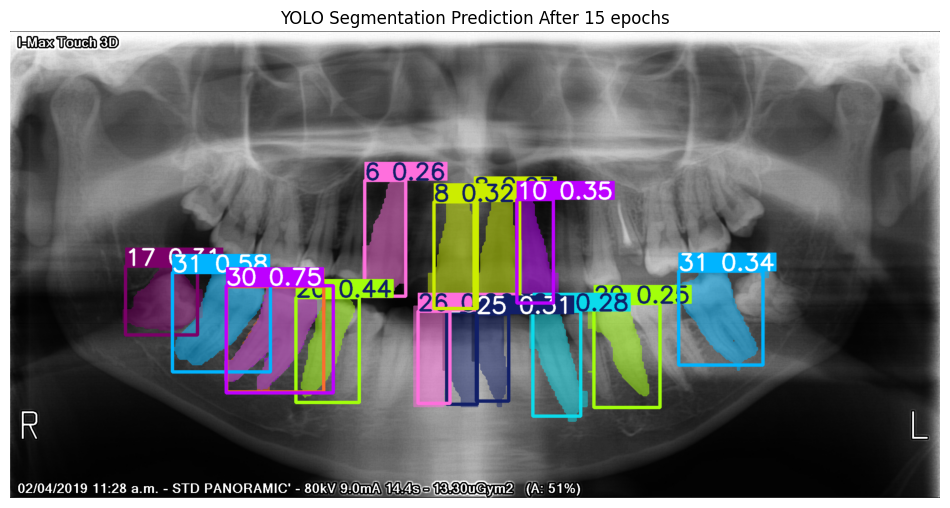


Extracted 15 masks with shape (288, 512)
Detected classes: [         29          30          18          19           9          30           7          24          16          21           7          25           5          19          24]


In [35]:
import cv2
import matplotlib.pyplot as plt
# we have model, resume_model and model_more_epochs for now
# Run inference on a single test image
# (using one of the test images listed in your directory)
test_img_path = data_dir / 'images/test/104.jpg'
# model_more_epochs is the latest trained model
results = model_more_epochs(str(test_img_path))

# Extract the first (and only) result
result = results[0]

# YOLO built-in visualization
res_plotted = result.plot()
res_plotted = cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB)

# Display the predicted image
plt.figure(figsize=(12, 12))
plt.imshow(res_plotted)
plt.axis('off')
plt.title('YOLO Segmentation Prediction After 15 epochs')
plt.show()

# Accessing raw mask data for custom post-processing:
if result.masks is not None:
    masks = result.masks.data.cpu().numpy()  # Extract masks as numpy arrays
    classes = result.boxes.cls.cpu().numpy() # Extract corresponding class IDs
    print(f"\nExtracted {masks.shape[0]} masks with shape {masks.shape[1:]}")
    print(f"Detected classes: {classes}")
else:
    print("\nNo masks detected in this image.")

### 1. Evaluation Metrics Definition
Here we define the functions to calculate Semantic Segmentation IoU and Bounding Box metrics (Precision, Recall, F1).

In [ ]:
# YOLO natively computes Precision, Recall, and mAP (which uses IoU thresholds).
# We will extract these directly from the validation results in the next cell.
print('Evaluation metrics will be extracted from YOLO\'s val_results object.')

### 2. Evaluation Loop
Run this cell to evaluate the model on the validation dataset.

In [36]:
# Evaluate YOLO model on the validation set -> 15 epochs
val_results = model_more_epochs.val(
    data=str(data_dir / 'data.yaml'),
    split='val',
    project='/content/yolo_eval',
    name='teeth_seg_val'
)

print('\n=== YOLO Segmentation Evaluation Results ===')

# YOLO calculates mean metrics across all classes
precision = val_results.seg.mp  # Mean Precision
recall = val_results.seg.mr     # Mean Recall

# Calculate F1 Score
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-score:  {f1_score:.4f}')
print(f'mAP@50:    {val_results.seg.map50:.4f}')
print(f'mAP@50-95: {val_results.seg.map:.4f}')

print('\nNote: In segmentation, mAP (mean Average Precision) is used instead of standard "Accuracy".')
print('mAP@50 means it considers a prediction correct if the Intersection over Union (IoU) > 0.50.')



Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2322.7±550.9 MB/s, size: 735.5 KB)
val: Scanning /content/teeth-segmentation-on-dental-x-ray-images/labels/val.cache... 59 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 59/59 10.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.9s/it 11.4s
                   all         59       1493       0.33      0.552      0.378      0.234      0.329      0.557      0.378      0.213
                     1         27         27      0.336       0.37      0.325      0.226      0.323       0.37      0.325      0.202
                     2         50         50      0.411      0.571      0.446      0.324      0.411        0.6      0.446      0.304
                     3         46         47      0.436      0.617      0.399      0.278      0.435      0.617  

In [37]:
# Evaluate YOLO model on the validation set -> 10 epochs
# Precision: 0.3020
# Recall:    0.5091
# F1-score:  0.3791
# mAP@50:    0.3130
# mAP@50-95: 0.1829
#
# Note: These metrics are low because 10-15 epochs is just a starting point.
# Training for 100+ epochs is highly recommended and standard practice for YOLO!

val_results = model.val(
    data=str(data_dir / 'data.yaml'),
    split='val',
    project='/content/yolo_eval',
    name='teeth_seg_val'
)

print('\n=== YOLO Segmentation Evaluation Results ===')

# YOLO calculates mean metrics across all classes
precision = val_results.seg.mp  # Mean Precision
recall = val_results.seg.mr     # Mean Recall

# Calculate F1 Score
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-score:  {f1_score:.4f}')
print(f'mAP@50:    {val_results.seg.map50:.4f}')
print(f'mAP@50-95: {val_results.seg.map:.4f}')

print('\nNote: In segmentation, mAP (mean Average Precision) is used instead of standard "Accuracy".')
print('mAP@50 means it considers a prediction correct if the Intersection over Union (IoU) > 0.50.')

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2220.8±549.3 MB/s, size: 798.1 KB)
val: Scanning /content/teeth-segmentation-on-dental-x-ray-images/labels/val.cache... 59 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 59/59 10.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 4.0s/it 16.0s
                   all         59       1493      0.303       0.51      0.314        0.2      0.302      0.509      0.313      0.183
                     1         27         27      0.376     0.0741      0.161      0.112      0.376     0.0741      0.161     0.0956
                     2         50         50      0.356       0.46      0.453      0.323      0.356       0.46      0.453      0.314
                     3         46         47      0.284      0.638       0.36      0.262      0.284      0.638  

## Extended Training Run (100 Epochs)
Here we will train a fresh YOLOv8 segmentation model for 100 epochs to compare against the shorter runs.

In [38]:
from ultralytics import YOLO

# Initialize a fresh YOLOv8 segmentation model so we don't overwrite the previous ones
model_100 = YOLO('yolov8n-seg.pt')

# Start extended training
print("Starting extended training for 100 epochs...")
results_100 = model_100.train(
    data=str(data_dir / 'data.yaml'),
    epochs=100,
    imgsz=512,
    batch=16,
    project='/content/yolo_train',
    name='teeth_seg_100epochs'
)

Starting extended training for 100 epochs...
Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/teeth-segmentation-on-dental-x-ray-images/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=teeth_seg_100epochs, nbs=64, nms

### Save the 100-Epoch Model to Drive

In [39]:
import os
import shutil

# Define paths for the new 100-epoch model
source_weights_100 = '/content/yolo_train/teeth_seg_100epochs/weights/best.pt'
drive_dest_dir_100 = '/content/drive/MyDrive/cv2/Teeth_Segmentation_Model_100epochs'

# Create the folder in Drive if it doesn't exist
os.makedirs(drive_dest_dir_100, exist_ok=True)

# Copy the file over
if os.path.exists(source_weights_100):
    shutil.copy(source_weights_100, os.path.join(drive_dest_dir_100, 'best.pt'))
    print(f"\nSuccess! 100-epoch model saved permanently to: {drive_dest_dir_100}/best.pt")
else:
    print("\nModel weights not found. Make sure the training cell above finished successfully.")


Success! 100-epoch model saved permanently to: /content/drive/MyDrive/cv2/Teeth_Segmentation_Model_100epochs/best.pt


### Inference & Evaluation (100 Epochs)


image 1/1 /content/teeth-segmentation-on-dental-x-ray-images/images/test/104.jpg: 288x512 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 2 13s, 1 14, 1 15, 1 16, 1 17, 1 18, 1 19, 2 20s, 1 21, 1 22, 1 23, 1 24, 1 25, 1 26, 1 27, 1 28, 1 29, 1 30, 1 31, 1 32, 95.7ms
Speed: 3.0ms preprocess, 95.7ms inference, 40.3ms postprocess per image at shape (1, 3, 288, 512)


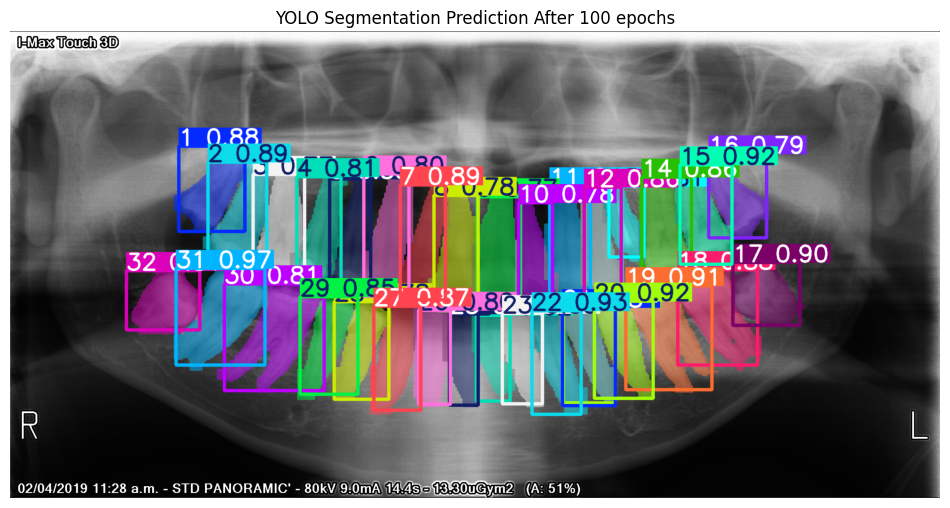

In [40]:
import cv2
import matplotlib.pyplot as plt

# Run inference on the same test image using the 100-epoch model
test_img_path = data_dir / 'images/test/104.jpg'
results_100_inf = model_100(str(test_img_path))

# Extract and plot
result_100 = results_100_inf[0]
res_plotted_100 = result_100.plot()
res_plotted_100 = cv2.cvtColor(res_plotted_100, cv2.COLOR_BGR2RGB)

# Display the predicted image
plt.figure(figsize=(12, 12))
plt.imshow(res_plotted_100)
plt.axis('off')
plt.title('YOLO Segmentation Prediction After 100 epochs')
plt.show()

In [41]:
# Evaluate the 100-epoch model on the validation set
val_results_100 = model_100.val(
    data=str(data_dir / 'data.yaml'),
    split='val',
    project='/content/yolo_eval',
    name='teeth_seg_val_100epochs'
)

print('\n=== YOLO Segmentation Evaluation Results (100 Epochs) ===')

precision_100 = val_results_100.seg.mp
recall_100 = val_results_100.seg.mr
f1_score_100 = 2 * (precision_100 * recall_100) / (precision_100 + recall_100) if (precision_100 + recall_100) > 0 else 0

print(f'Precision: {precision_100:.4f}')
print(f'Recall:    {recall_100:.4f}')
print(f'F1-score:  {f1_score_100:.4f}')
print(f'mAP@50:    {val_results_100.seg.map50:.4f}')
print(f'mAP@50-95: {val_results_100.seg.map:.4f}')

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (AMD EPYC 7B12)
val: Fast image access ✅ (ping: 0.1±0.1 ms, read: 152.6±50.6 MB/s, size: 784.3 KB)
val: Scanning /content/teeth-segmentation-on-dental-x-ray-images/labels/val.cache... 59 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 59/59 13.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.8s/it 11.2s
                   all         59       1493       0.89      0.894      0.949      0.628      0.885      0.897      0.946       0.56
                     1         27         27      0.903      0.889      0.962       0.59      0.886      0.889      0.962      0.589
                     2         50         50      0.793       0.84      0.939      0.717      0.797      0.864      0.939      0.692
                     3         46         47      0.871      0.851      0.942      0.671       0.87      0.856    